In [ ]:
import tidy3d as td
from tidy3d import web

import numpy as np
import matplotlib.pyplot as plt

#resolution = 30 #[px/um]

#all dimensions in [um]
lda0 = 1.55
freq0 = td.C_0 / lda0
fwidth = freq0 / 10

dpml = 1.0 #PML thickness
dsub = 0.6*lda0 #substrate thickness
#dpad = dsub #padding between cell and PML

n_si = 3.45 #silicon refractive index
si = td.Medium(permittivity = n_si ** 2)
n_sio2 = 1.45
sio2 = td.Medium(permittivity = n_sio2 ** 2)
n_air = 1.0 #air refractive index
air = td.Medium(permittivity = n_air ** 2)

P = 0.7 #unit cell pitch [um]
unit_cell_pitch = P
h = 0.9 #pillar height [um]

#propgation distances
d0 = 535 #[um]
d1 = 415 #[um]
d2 = d0 #[um]

Nx = 1025 #pixels per dimension
Ny = Nx
nx = (Nx - 1) // 2 #indices without axes (= #512)
ny = (Ny - 1) // 2
dof = 2*((nx + 1)**2) #number of degrees of freedom per metasurface
S = Nx * Ny

size_x = unit_cell_pitch * Nx #actual physical size
size_y = unit_cell_pitch * Ny

xs = np.arange(-Nx//2+1, Nx//2+1) * (size_x / Nx)
ys = np.arange(-Ny//2+1, Ny//2+1) * (size_y / Ny)
print(xs[0],xs[-1])
X, Y = np.meshgrid(xs, ys)
rho = np.sqrt(X**2 + Y**2)

-358.4 358.4


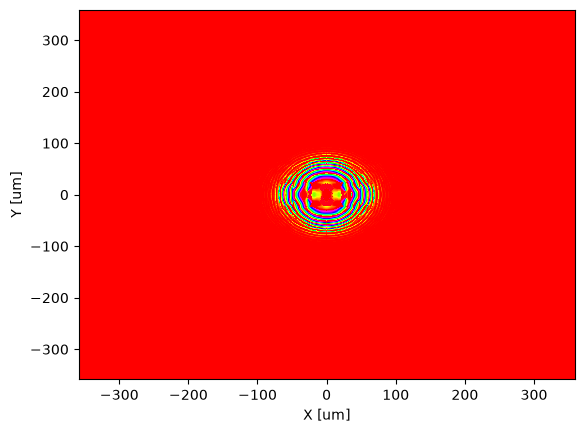

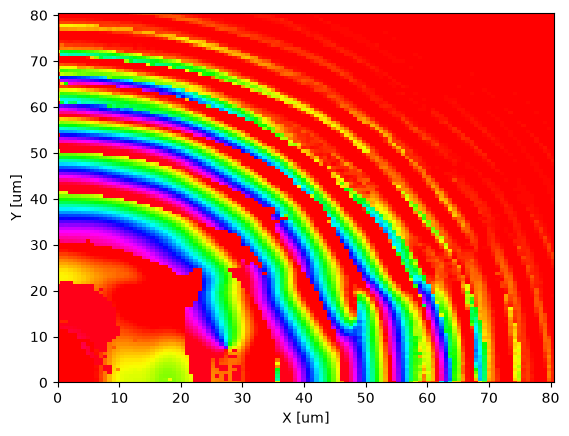

In [26]:
####################################################
#LOAD PHASE MASKS
#___________________________________________________
#load the phase mask data
phase_mask_filename = "../results_sym/optimized_phase_mask_1.npy"
phase_mask = np.load(phase_mask_filename)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, phase_mask, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

sim_domain_pixel_size = 230 #full simulation domain (full axis)
sim_domain_size = sim_domain_pixel_size * unit_cell_pitch
max_sim_radius = 75

X_quadrant = X[nx:, ny:]
xs_quadrant = xs[nx:]
xs_sim = xs[np.abs(xs) <= sim_domain_size/2]
xs_sim_quadrant = xs_quadrant[np.abs(xs_quadrant) <= sim_domain_size/2]

Y_quadrant = Y[nx:, ny:]
ys_quadrant = ys[ny:]
ys_sim = ys[np.abs(ys) <= sim_domain_size/2]
ys_sim_quadrant = ys_quadrant[np.abs(ys_quadrant) <= sim_domain_size/2]

X_sim, Y_sim = np.meshgrid(xs_sim, ys_sim)

phase_mask_quadrant = phase_mask[nx:, ny:]

fig, ax = plt.subplots()
im = ax.pcolormesh(X_quadrant, Y_quadrant, phase_mask_quadrant, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_ybound(0,sim_domain_size/2)
ax.set_xbound(0,sim_domain_size/2)
fig.show()


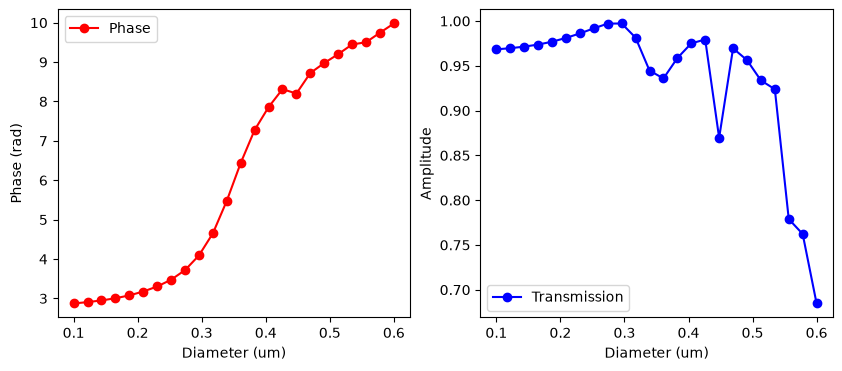

In [27]:
####################################################
#UNIT CELL DATA
#___________________________________________________
#import the unit-cell transmission coefficient data
unit_cell_diameters = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_diameters.npy")
unit_cell_mode_phase = np.unwrap(np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_phase.npy"))
unit_cell_mode_tran = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_tran.npy")

#make a plot of the unit-cell transmission coefficient
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(unit_cell_diameters, unit_cell_mode_phase, 'r-', marker='o', label='Phase')
ax[0].set_xlabel('Diameter (um)')
ax[0].set_ylabel('Phase (rad)')
ax[1].plot(unit_cell_diameters, unit_cell_mode_tran, 'b-', marker='o', label='Transmission')
ax[1].set_xlabel('Diameter (um)')
ax[1].set_ylabel('Amplitude')
ax[0].legend()
ax[1].legend()
plt.show()
####################################################

In [28]:
pillars_geo = []
D_vals = []
theta = unit_cell_mode_phase

for i, x in enumerate(xs_sim_quadrant):
    for j, y in enumerate(ys_sim_quadrant):
        if np.sqrt(x**2 + y**2) > max_sim_radius:
            continue
        else:
            required_diameter = np.interp(phase_mask_quadrant[i,j], theta, unit_cell_diameters)
            #round the required diameter up to three decimal places (nm)
            required_diameter = np.round(required_diameter, 3)
            D_vals.append(required_diameter)
            pillar_geo = td.Cylinder(center=(x, y, h/2), radius=required_diameter/2, length=h)
            pillars_geo.append(pillar_geo)
print("Number of pillars in simulation domain: ", len(pillars_geo))
pillars = td.Structure(geometry=td.GeometryGroup(geometries=pillars_geo), medium=si)

Number of pillars in simulation domain:  9124


In [ ]:
#simulation domain setup, using mirror symmetry along x and y axes
Lx = sim_domain_size
Ly = sim_domain_size
Lz = h + 2*dsub

#far field points for projection monitor
xs_far = np.linspace(-Lx/2, Lx/2, 101)
ys_far = np.linspace(-Ly/2, Ly/2, 101)
X_far, Y_far = np.meshgrid(xs_far, ys_far)

projection_distance = d1 + h

monitor_proj = td.FieldProjectionCartesianMonitor(
    center=[0, 0, h + 0.5*lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="ff_proj_monitor",
    proj_axis=2,
    proj_distance= projection_distance,
    x=xs_far,
    y=ys_far,
    custom_origin=(0, 0, 0),
    far_field_approx=False,
)

inf_eff = 1e5
substrate_geo = td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, 0))
substrate = td.Structure(geometry=substrate_geo, medium=sio2)

#simulation
run_time = 5e-12
min_steps_per_wvl = 12

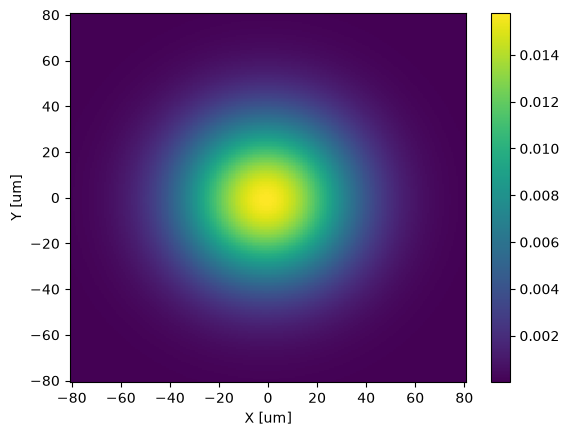

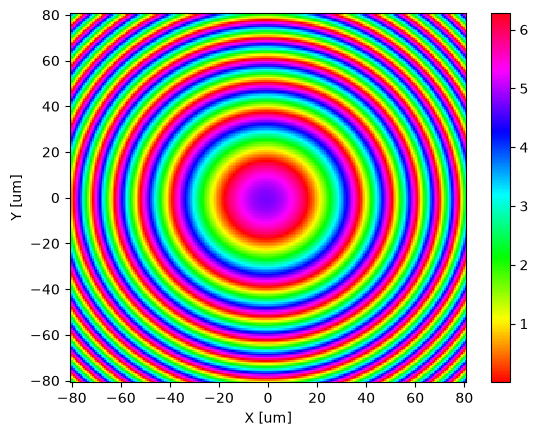

In [30]:
#import the input field (just before MS1)
input_field_before_MS1 = np.load("../results_sym/input_field_before_MS1.npy")

mask = (np.abs(X) <= sim_domain_size/2) & (np.abs(Y) <= sim_domain_size/2)
input_field_before_MS1_sim = input_field_before_MS1[mask].reshape(len(xs_sim), len(ys_sim))

fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, np.abs(input_field_before_MS1_sim))
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.colorbar(im, ax=ax)
fig,ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, (np.angle(input_field_before_MS1_sim)+2*np.pi)%(2*np.pi), cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.colorbar(im, ax=ax)

In [ ]:
#define the source field dataset
source_position = -lda0 / 2
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)

source_x_size = sim_domain_size
source_y_size = sim_domain_size

source_sim = input_field_before_MS1_sim
medium_impedance = td.ETA_0 / n_sio2

dataset_input_EH = td.FieldDataset(
    Ex = td.ScalarFieldDataArray(
        source_sim[..., None, None],
        coords={
            "x": xs_sim,
            "y": ys_sim,
            "z": [source_position],
            "f": [freq0],
        },
    ),
    Hy = td.ScalarFieldDataArray(
        source_sim[..., None, None] / medium_impedance,
        coords={
            "x": xs_sim,
            "y": ys_sim,
            "z": [source_position],
            "f": [freq0],
        },
    ),
)

custom_src = td.CustomFieldSource(
    source_time = source_time,
    center = (0,0,source_position),
    size = (source_x_size,source_y_size,0),
    field_dataset = dataset_input_EH
)

161.0 161.0


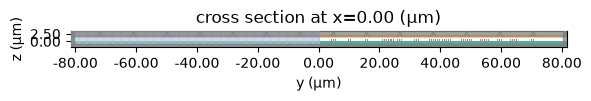

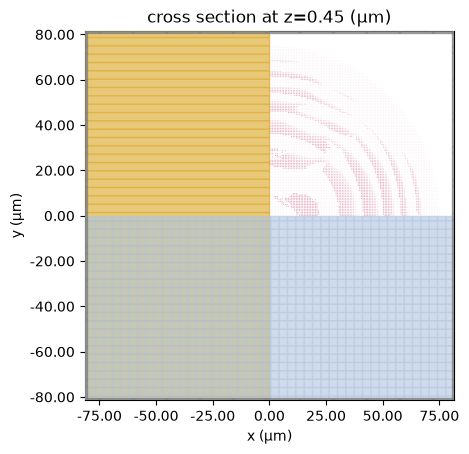

In [ ]:
sim = td.Simulation(
    center=[0, 0, h/2],
    size=[Lx, Ly, Lz],
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=lda0),
    structures=[substrate, pillars],
    sources=[custom_src],
    monitors=[monitor_proj],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()),
    symmetry=[-1,1,0],
)

fig, ax = plt.subplots()
sim.plot(x=0, ax=ax)
plt.show()

fig, ax = plt.subplots()
sim.plot(z=h/2, ax=ax)
plt.show()

In [33]:
job = web.Job(simulation=sim, task_name="full_meta1")
estimated_cost = web.estimate_cost(job.task_id)

17:15:49 CEST Created task 'full_meta1' with resource_id                        
              'fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=15528635;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=15528636;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\taskId]8;;\]8;id=15528635;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\=]8;;\]8;id=15528637;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\fdve]8;;\]8;id=15528635;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\-3a7e3b46-25]8;;\
              ]8;id=15528635;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3a7e3b46-25d2-48a5-a1d5-e5678140eba0\d2-48a5-a1d5-e5678140eba0']8;;\.

              Task folder: ]8;id=15528640;https://tidy3d.simulation.cloud/folders/folder-6fa00d15-cb0e-4116-8177-44b5787077db\'default']8;;\.

Output()

17:16:03 CEST Estimated FlexCredit cost: 6.418. This assumes the FDTD solver    
              runs for the full simulation time; if early shutoff is reached,   
              the billed cost can be lower. Use 'web.real_cost(task_id)' to get 
              the billed FlexCredit cost after a simulation run.

In [ ]:
#sim_data = job.run(path="tidy3d_results/full_meta1.hdf5")

In [ ]:
proj_fields = sim_data["ff_proj_monitor"].fields_cartesian.Ex.sel(f=freq0, z=projection_distance)

fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)

im0 = ax[0].pcolormesh(X_far, Y_far, np.abs(proj_fields), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("FDTD - Projected Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(X_far, Y_far, (np.angle(proj_fields)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_title("FDTD - Projected Phase", fontsize=15, pad=15)
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)